In [79]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import math


def save_fig(name):
    plt.savefig(os.path.join("../Data", name), dpi=300, bbox_inches='tight')


name = 'sar_3.jpg'
image = cv2.imread(name)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# 1. Для изображения sar_3.jpg найти наиболее протяженный участок (выделить линии при помощи преобразования Хафа)

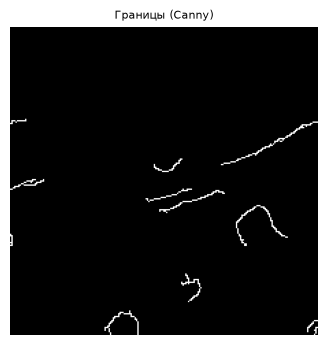

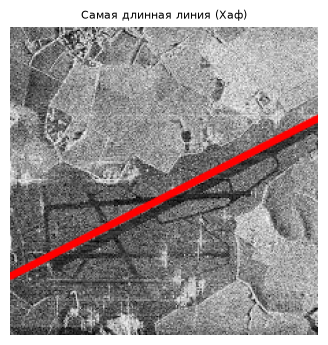

In [80]:
image_gray_no_noise = cv2.medianBlur(image_gray, 13)

# Детектор границ
edges = cv2.Canny(image_gray_no_noise, 50, 150, apertureSize=3)

plt.figure(figsize=(5, 4))
plt.title("Границы (Canny)", fontsize=8)
plt.imshow(edges, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.axis('off')
save_fig("Canny.png")

# Преобразование Хафа
lines = cv2.HoughLines(edges, 1, np.pi / 180, 47)

line_img = image.copy()

ys, xs = np.where(edges > 0)

best = None
mx = 0

# Ищем линии
if lines is not None:
    for i in range(len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]

        cnt = 0
        for j in range(len(xs)):
            d = abs(xs[j] * math.cos(theta) + ys[j] * math.sin(theta) - rho)
            if d < 1.0:
                cnt += 1

        if cnt > mx:
            mx = cnt
            best = (rho, theta)



if best is not None:
    rho, theta = best
    a = math.cos(theta)
    b = math.sin(theta)
    x0 = a * rho
    y0 = b * rho

    pt1 = (int(x0 + 300 * (-b)), int(y0 + 300 * (a)))
    pt2 = (int(x0 - 300 * (-b)), int(y0 - 300 * (a)))

    cv2.line(line_img, pt1, pt2, (0, 0, 255), 3, cv2.LINE_AA)

plt.figure(figsize=(5, 4))
plt.title("Самая длинная линия (Хаф)", fontsize=8)
plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.xticks([])
plt.yticks([])
plt.axis('off')
save_fig("LongestLine.png")


# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

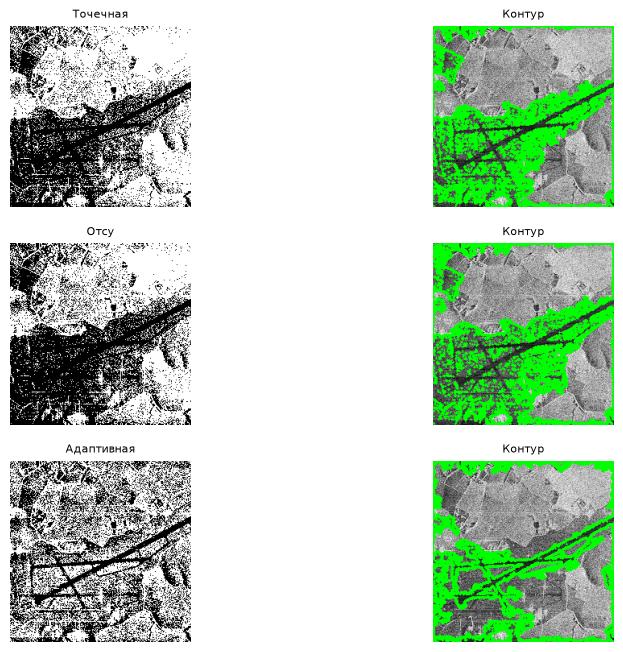

In [81]:
# Точечная
_, th_simple = cv2.threshold(image_gray, 120, 255, cv2.THRESH_BINARY)

# Отсу
_, th_otsu = cv2.threshold(image_gray, 0, 255,
                           cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Адаптивная
th_adapt = cv2.adaptiveThreshold(
    image_gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    35,
    5
)

plt.figure(figsize=(10, 8))

# Точечная
plt.subplot(3, 2, 1)
plt.title("Точечная", fontsize=8)
plt.imshow(th_simple, cmap='gray')
plt.axis('off')

contours, _ = cv2.findContours(th_simple, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
simple_contours = image.copy()
cv2.drawContours(simple_contours, contours, -1, (0, 255, 0), 2)

plt.subplot(3, 2, 2)
plt.title("Контур", fontsize=8)
plt.imshow(cv2.cvtColor(simple_contours, cv2.COLOR_BGR2RGB))
plt.axis('off')


# Отсу
plt.subplot(3, 2, 3)
plt.title("Отсу", fontsize=8)
plt.imshow(th_otsu, cmap='gray')
plt.axis('off')

contours, _ = cv2.findContours(th_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
otsu_contours = image.copy()
cv2.drawContours(otsu_contours, contours, -1, (0, 255, 0), 2)

plt.subplot(3, 2, 4)
plt.title("Контур", fontsize=8)
plt.imshow(cv2.cvtColor(otsu_contours, cv2.COLOR_BGR2RGB))
plt.axis('off')


# Адаптивная
plt.subplot(3, 2, 5)
plt.title("Адаптивная", fontsize=8)
plt.imshow(th_adapt, cmap='gray')
plt.axis('off')

contours, _ = cv2.findContours(th_adapt, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
adapt_contours = image.copy()
cv2.drawContours(adapt_contours, contours, -1, (0, 255, 0), 2)

plt.subplot(3, 2, 6)
plt.title("Контур", fontsize=8)
plt.imshow(cv2.cvtColor(adapt_contours, cv2.COLOR_BGR2RGB))
plt.axis('off')

save_fig("Binarization.png")
plt.show()
